### Advanced modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df_tr = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_train_eda.csv')
df_test = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_test_eda.csv')

In [61]:
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')
df_test = df_test.merge(
    df_testt,
    on = ['shop_id','item_id'],
    how = 'left'
)

In [5]:
import sys
sys.path.append("..")

In [6]:
from scripts.expanding_window_splitter import ExpandingWindowSplitter
from scripts.expanding_validator import ExpandingValidator

In [15]:
from scripts.splitter import Splitter

splitter = Splitter('date_block_num', 33)


Feature importance

In [16]:
features =['item_price','shop_id','item_id', 'simple_category_id', 'cnt_lag_1','cnt_lag_3','cnt_lag_2','cnt_lag_12', 'cnt_rm_3','cnt_rm_6','item_avg_price_prev','date_block_num','avg_price_prev_missing']
X_tr, y_tr, X_val, y_val = splitter.split(df_tr, features,'item_cnt_month')


In [64]:
X_tr_full = pd.concat([X_tr, X_val], axis = 0)
y_tr_full = pd.concat([y_tr, y_val])

In [57]:
from sklearn.ensemble import RandomForestRegressor


In [ ]:
modelRFR = RandomForestRegressor(n_estimators = 200, max_depth = 10, random_state= 42, n_jobs = -1)

In [ ]:
modelRFR.fit(X_tr,y_tr)

In [ ]:
imp = pd.Series(modelRFR.feature_importances_, index = X_tr.columns).sort_values(ascending=False)

In [ ]:
imp

item_price                0.565264
cnt_lag_1                 0.324928
cnt_rm_6                  0.050793
item_avg_price_prev       0.024062
date_block_num            0.018359
cnt_lag_3                 0.009237
cnt_lag_2                 0.005839
cnt_lag_12                0.001424
avg_price_prev_missing    0.000095
dtype: float64

item_price + cnt_lag_1 дают почти 90 процентов важности

Интересный факт: цена имеет наибольшую важность, но корреляция у цены с таргетом маленькая (0.35)

Значит скорее всего присутствует какая-то коварная нелинейная связь между ними.

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(modelRFR, X_val, y_val, n_repeats = 10, random_state = 42, n_jobs = -1)
 

In [ ]:
perm_imp = pd.Series(perm.importances_mean, index = X_val.columns).sort_values(ascending=False)
perm_imp 

item_price                0.865597
cnt_lag_1                 0.109554
cnt_rm_6                  0.051026
item_avg_price_prev       0.024206
cnt_lag_2                 0.003526
cnt_lag_3                 0.003377
cnt_lag_12                0.002025
avg_price_prev_missing    0.000003
date_block_num            0.000000
dtype: float64

видим, что  после перестановки топовые лидеры по важности: item_price   cnt_lag_1   cnt_rm_6

Hyperparameter optimization job

In [ ]:
from hyperopt import hp, Trials, fmin, tpe, STATUS_OK

d:\repos\ML_innovise\.venv\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

In [ ]:
space = {
    'n_estimators': hp.choice('n_estimators', [50, 100] ),
    'max_depth': hp.choice('max_depth', [5,10]),
    'min_samples_split': hp.quniform('min_samples_split', 2,5,1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 3, 1),
}

splitter = TimeSeriesSplit(n_splits = 5)

def objective(params):
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['min_samples_split'] = int(params['min_samples_split'])

    model = RandomForestRegressor(
        n_estimators = params['n_estimators'],
        max_depth = params['max_depth'],
        min_samples_split = params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=42
        )
    metric = cross_val_score(model, X_tr, y_tr, cv = splitter, scoring = 'neg_mean_squared_error', n_jobs = -1).mean()
    return {
        'loss': -metric,
        'status': STATUS_OK
    }

trials = Trials()
best = fmin(
    fn = objective,
    space = space,
    algo = tpe.suggest,
    max_evals = 30,
    trials = trials,
)

print(best)



100%|██████████| 30/30 [2:44:46<00:00, 329.56s/trial, best loss: 0.4027374525028648] 
{'max_depth': np.int64(1), 'min_samples_leaf': np.float64(3.0), 'min_samples_split': np.float64(5.0), 'n_estimators': np.int64(1)}


получается имеем -> 
{
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'min_samples_leaf': 3
    }

In [ ]:
n_estimators_list = [50, 100]
max_depth_list    = [5, 10]

best_params = {
    'n_estimators':      n_estimators_list[ int(best['n_estimators']) ],
    'max_depth':         max_depth_list[    int(best['max_depth'])    ],
    'min_samples_split': int(best['min_samples_split']),
    'min_samples_leaf':  int(best['min_samples_leaf'])
}

final_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_tr, y_tr)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
preds = final_model.predict(df_test[features])


In [ ]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  preds
})

In [ ]:
submission.to_csv("RFR_Hyperopt.csv", index=False)

Результат - 1.23658

Тут я подумала и решила, что раз Ridge показал свой лучший результат, то почему бы не попробовал подобрать альфа с помощью оптимизации

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
space = {
    'alpha': hp.loguniform('alpha', np.log(1e-4), np.log(1e2))
}
tscv = TimeSeriesSplit(n_splits=5)
def objective(params):
    model = Ridge(alpha = params['alpha'], random_state = 42)
    metric = cross_val_score(model, X_tr, y_tr, cv = tscv, scoring  = 'neg_mean_squared_error', n_jobs = -1).mean()
    return{
        'loss': -metric,
        'status': STATUS_OK
    }
trials = Trials()
best = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 15, trials = trials, )
print('Best alpha:', best['alpha'])

100%|██████████| 15/15 [00:50<00:00,  3.40s/trial, best loss: 0.6061698965738761]
Best alpha: 0.00038128326956847947


In [ ]:
alpha_opt = best['alpha']
model = Ridge(alpha = alpha_opt)
model.fit(X_tr, y_tr)
preds = model.predict(df_test[features])


In [ ]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  preds
})

In [ ]:
submission.to_csv("RidgeAlphaOpt2.csv", index=False)

Результат - 1.03091

In [ ]:
import xgboost as xgb

In [ ]:
space = {
    'max_depth': hp.choice('max_depth', np.arange(3,13,dtype = int)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'n_estimators': hp.choice('n_estimators', np.arange(100,701, 100, dtype = int)),
}

In [ ]:
tscv = TimeSeriesSplit(n_splits=3)


In [ ]:
def objective(params):
    model = xgb.XGBRegressor(**params, objective = 'reg:squarederror', random_state = 42, n_jobs  = -1)
    scores = cross_val_score(model, X_tr_full, y_tr_full,  scoring = 'neg_root_mean_squared_error', cv = tscv, n_jobs = -1)
    rmse_mean = -scores.mean()
    return{
        'loss': rmse_mean,
        'status': STATUS_OK
    }


In [ ]:
trials = Trials()
best = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 50, trials = trials)
print(best)

100%|██████████| 50/50 [2:41:21<00:00, 193.63s/trial, best loss: 0.5891115539691306]  
{'learning_rate': np.float64(0.049476130747775356), 'max_depth': np.int64(7), 'n_estimators': np.int64(5)}


In [ ]:
from hyperopt import space_eval


In [ ]:
best_params = space_eval(space, best)
print(best_params)

{'learning_rate': 0.049476130747775356, 'max_depth': np.int64(10), 'n_estimators': np.int64(600)}


Получается лучшие параметры для XGBoost:

- learning_rate': 0.049476130747775356
- 'max_depth': 10
- 'n_estimators': 600

In [ ]:
best_model = xgb.XGBRegressor(learning_rate = 0.049476130747775356, max_depth = 10, n_estimators = 600)

In [ ]:
best_model.fit(X_tr_full, y_tr_full)
X_test = df_test[features]
pred = best_model.predict(X_test)

In [ ]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  pred
})

In [ ]:
# результат на кагле - 1.19305
submission.to_csv("XGB_hyperopt.csv", index=False)

## Explainability layer

In [ ]:
import shap

d:\repos\ML_innovise\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
segments = []
for start in np.random.choice(range(len(X_tr_full)-5), size=20, replace=False):
    segments.append(X_tr_full.iloc[start:start+5])
background = pd.concat(segments)


In [ ]:
explainer = shap.TreeExplainer(best_model, data = background)


In [ ]:
idx = 100
instance = X_test.iloc[[idx]]
shap_values = explainer(instance)

In [ ]:
base = shap_values.base_values[0]
contributions = shap_values.values[0]

print("base value", base)
print("feature contributions:", contributions)# Видим, какие признаки тянут прогноз вверх (короче положительные вклады) и вниз (отрицательные).

base value 0.024902369933329675
feature contributions: [-4.76784073e-06  3.02610359e-06 -2.16288481e-05  0.00000000e+00
 -3.34144680e-06 -9.97380737e-06 -2.61227773e-03 -2.20580664e-02
 -1.33892662e-04  5.59465457e-06]


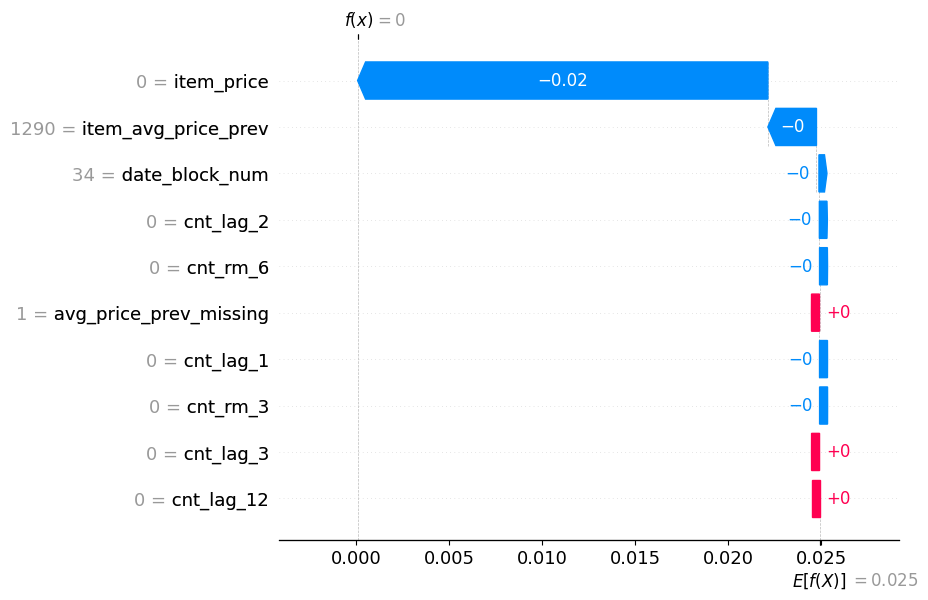

In [ ]:
# это наш waterfall график, который поможет посмотреть, как каждый признак вел наше предсказание до самого конца 
shap.waterfall_plot(shap_values[0])


In [ ]:
pd.DataFrame({
    'feature': X_test.columns,
    'shap_value': contributions
}).sort_values('shap_value', ascending=False)


,feature,shap_value
9,avg_price_prev_missing,0.000006
1,cnt_lag_3,0.000003
3,cnt_lag_12,0.000000
4,cnt_rm_3,-0.000003
0,cnt_lag_1,-0.000005
5,cnt_rm_6,-0.000010
2,cnt_lag_2,-0.000022
8,date_block_num,-0.000134
6,item_avg_price_prev,-0.002612
7,item_price,-0.022058


## Error analysis layer 

Слой анализа ошибок:
- найти слабые места модели
- как предсказывает большие значения таргета
- оценить точность прогноза при большой\малой дин

Я решила, поскольку лучший результат дала Линейная регрессия, то слой анализа ошибок я буду делать именно для нее. 


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
modelLR = LinearRegression()

In [19]:
def show_fold_errors(validator, df, feature_cols, target_col, figsize=(10,5)):
    
    fold_metrics, all_preds_df = validator.run(df, feature_cols, target_col)

    folds_df = pd.DataFrame(fold_metrics)
    folds_df = folds_df.sort_values('val_month').reset_index(drop=True)

    print("validation metrics in month:")
    print(folds_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(folds_df['val_month'], folds_df['val_score'], marker='o', linestyle='-', color='tab:blue')
    ax.set_xlabel('val_month')
    ax.set_ylabel('val_score', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_title('Validation score by month')

    mean_score = folds_df['val_score'].mean()
    ax.axhline(mean_score, color='tab:green', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

    return folds_df, all_preds_df


In [12]:
from sklearn.metrics import mean_squared_error

validation metrics in month:
 val_month  val_score
        13   0.438545
        14   0.721899
        15   0.476743
        16   0.570193
        17   0.463855
        18   0.483023
        19   0.576906
        20   0.639382
        21   0.723340
        22   1.029259
        23   1.362366
        24   0.687911
        25   0.666158
        26   0.626263
        27   0.786797
        28   0.652957
        29   0.545175
        30   0.440991
        31   0.580818
        32   0.799734
        33   0.815271


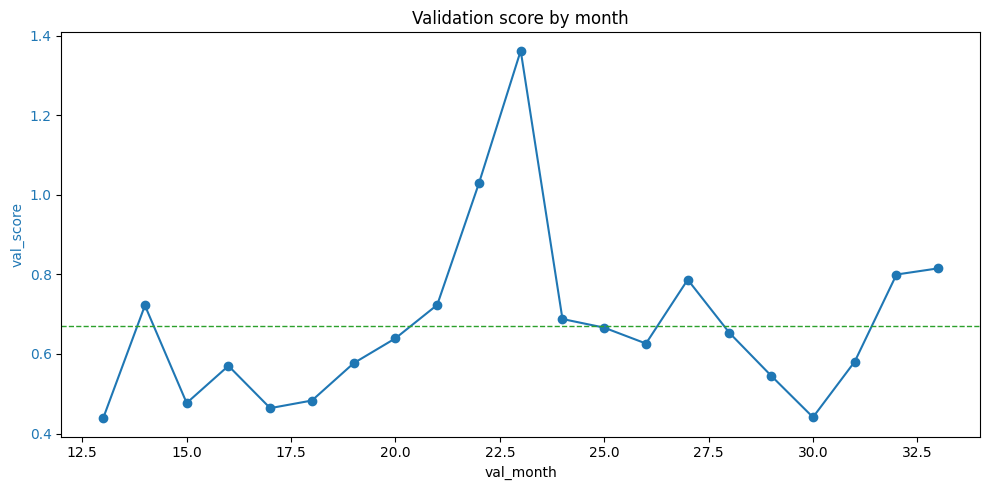

In [20]:
splitter = ExpandingWindowSplitter(time_col = 'date_block_num', first_val_month=13, last_val_month=33)
metric = mean_squared_error
validator  = ExpandingValidator(model = modelLR, splitter = splitter, metric = metric)
folds_df, all_preds_df = show_fold_errors(validator, df_tr, features, target_col = 'item_cnt_month')


Что видим:

- в среднем у нас ошибка на валидации - 0.7 (зеленая линия)
- есть месяцы - где ошибка экстремально скакнула (самые высокие - 22 и 23 месяц  - возможно в этих месяцах впервые появились новые/редкие товары)

In [27]:


def analyze_worst_month_residuals(folds_df, all_preds_df, validator, worst_k=3, top_n=20, figsize=(12,4)):
   
 
    time_col = validator.splitter.time_col
    results = {}

    worst_months = folds_df.sort_values('val_score', ascending=False).head(worst_k)['val_month'].tolist()

    for m in worst_months:
        sub = all_preds_df[all_preds_df[time_col] == m].copy()
        if sub.empty:
            print(f"Month {m}: no data, skipping")
            continue

        sub['residual'] = sub['y_true'] - sub['y_pred']
        sub['abs_residual'] = sub['residual'].abs()

        mean_abs = float(sub['abs_residual'].mean())
        median_abs = float(sub['abs_residual'].median())
        stats_series = pd.Series({
            'mean_abs_residual': mean_abs,
            'median_abs_residual': median_abs
        })

        top_errors = sub.sort_values('abs_residual', ascending=False).head(top_n)
        cols_keep = [time_col, 'y_true', 'y_pred', 'residual', 'abs_residual'] + \
                    [c for c in ['shop_id','item_id','item_category_id'] if c in sub.columns]
        top_errors = top_errors.loc[:, [c for c in cols_keep if c in top_errors.columns]]

        plt.figure(figsize=figsize)
        ax = plt.gca()
        sns.histplot(sub['residual'], bins=50, kde=True, color='tab:blue', ax=ax)
        ax.set_title(f'Residuals distribution for val_month {m} (n={len(sub)})')
        ax.set_xlabel('residual = y_true - y_pred')
        ax.axvline(0, color='k', linestyle='--', linewidth=1)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6,6))
        ax = plt.gca()
        sns.scatterplot(x='y_true', y='y_pred', data=sub, alpha=0.6, s=20, edgecolor=None, ax=ax)
        lims = [np.nanmin([sub['y_true'].min(), sub['y_pred'].min()]),
                np.nanmax([sub['y_true'].max(), sub['y_pred'].max()])]
        ax.plot(lims, lims, '--', color='red', linewidth=1)
        ax.set_xlabel('y_true')
        ax.set_ylabel('y_pred')
        ax.set_title(f'Прогноз vs Реальность (val_month={m})')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8,4))
        ax = plt.gca()
        sns.scatterplot(x='y_pred', y='residual', data=sub, alpha=0.6, s=20, edgecolor=None, ax=ax)
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('y_pred')
        ax.set_ylabel('residual = y_true - y_pred')
        ax.set_title(f'Residuals vs Predicted (val_month={m})')
        plt.tight_layout()
        plt.show()

        print(f"Month {m}")
        print(stats_series.to_string())
        print(f"Top {top_n} absolute residuals for month {m}:")
        print(top_errors.head(top_n).to_string(index=False))
        print("\n")

        results[m] = {
            'stats': stats_series,
            'top_errors_df': top_errors,
            'all_residuals': sub[['residual','abs_residual']]
        }

    return results


Рассмотрим самые худшие месяцы более внимательно:

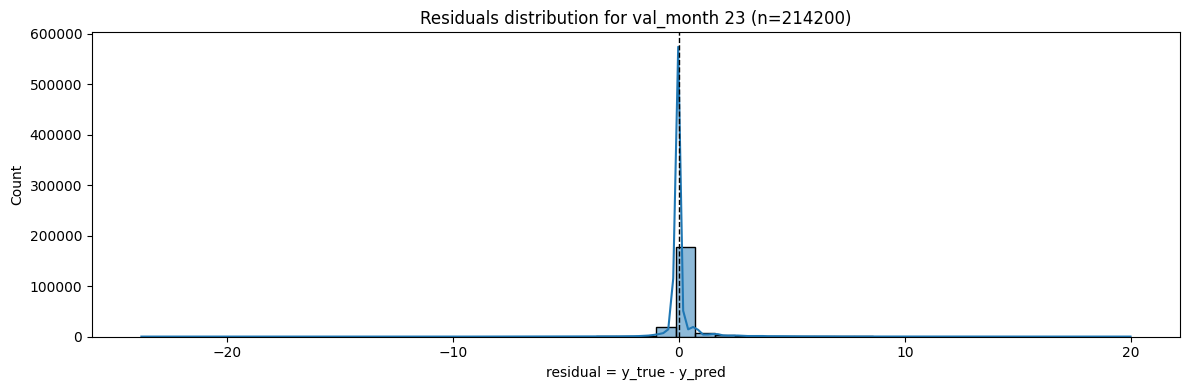

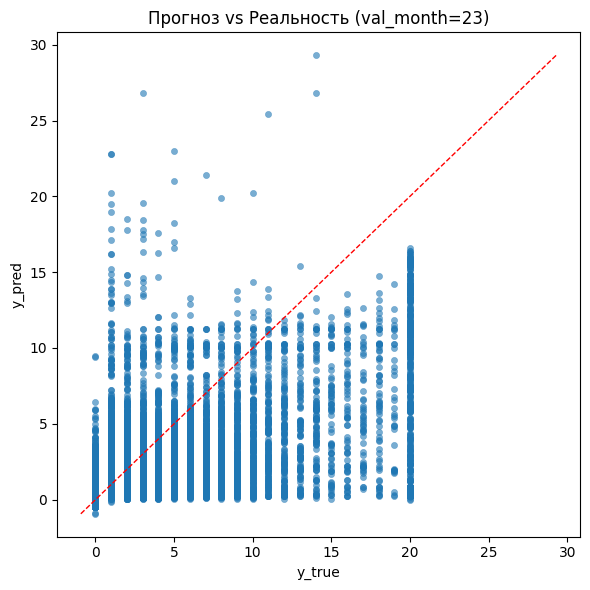

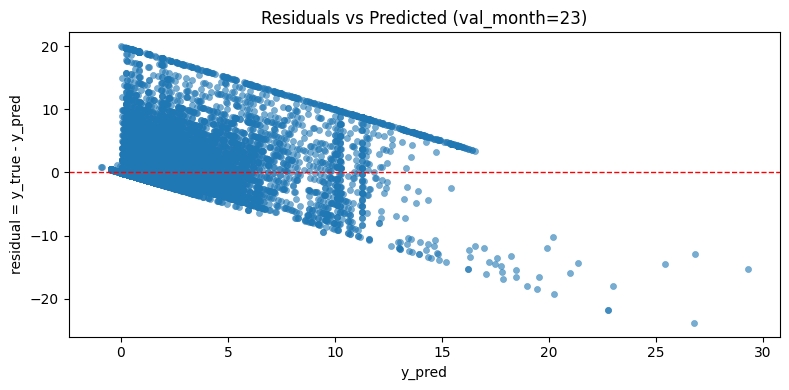

Month 23
mean_abs_residual      0.314593
median_abs_residual    0.047754
Top 20 absolute residuals for month 23:
 date_block_num  y_true    y_pred   residual  abs_residual
             23     3.0 26.787548 -23.787548     23.787548
             23     1.0 22.788219 -21.788219     21.788219
             23     1.0 22.787246 -21.787246     21.787246
             23    20.0  0.007777  19.992223     19.992223
             23    20.0  0.069381  19.930619     19.930619
             23    20.0  0.179937  19.820063     19.820063
             23    20.0  0.233254  19.766746     19.766746
             23    20.0  0.234254  19.765746     19.765746
             23    20.0  0.234433  19.765567     19.765567
             23    20.0  0.235635  19.764365     19.764365
             23    20.0  0.235982  19.764018     19.764018
             23    20.0  0.237636  19.762364     19.762364
             23    20.0  0.237752  19.762248     19.762248
             23    20.0  0.238562  19.761438     19.761438
  

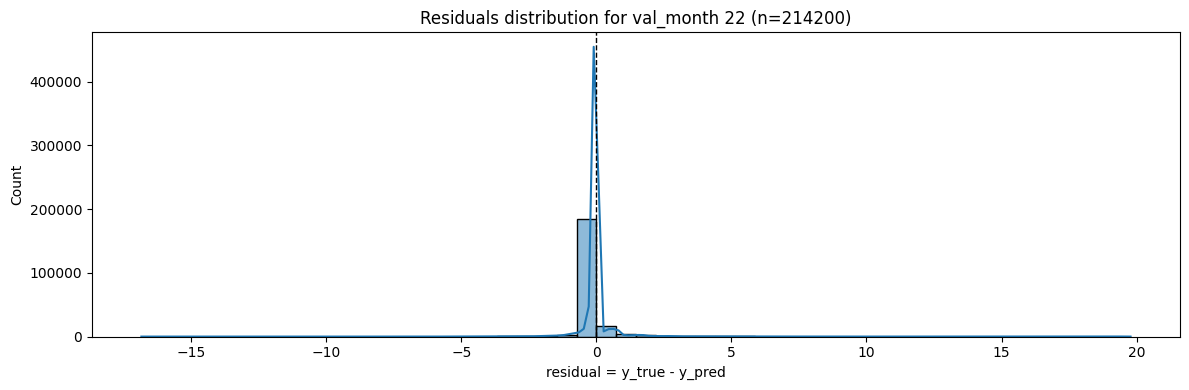

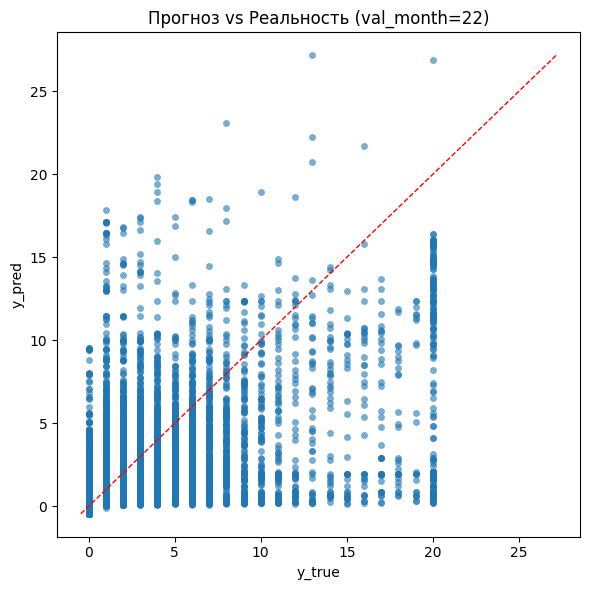

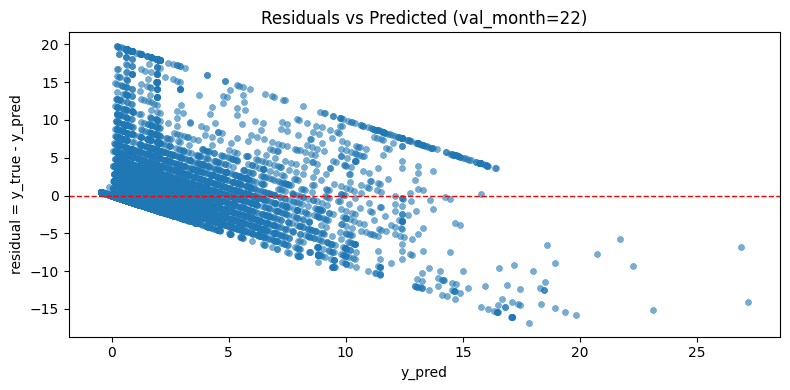

Month 22
mean_abs_residual      0.230093
median_abs_residual    0.040352
Top 20 absolute residuals for month 22:
 date_block_num  y_true   y_pred  residual  abs_residual
             22    20.0 0.225299 19.774701     19.774701
             22    20.0 0.225664 19.774336     19.774336
             22    20.0 0.286163 19.713837     19.713837
             22    20.0 0.293338 19.706662     19.706662
             22    20.0 0.395791 19.604209     19.604209
             22    20.0 0.470348 19.529652     19.529652
             22    20.0 0.601009 19.398991     19.398991
             22    20.0 0.604516 19.395484     19.395484
             22    20.0 0.607535 19.392465     19.392465
             22    20.0 0.607728 19.392272     19.392272
             22    20.0 0.608303 19.391697     19.391697
             22    20.0 0.609247 19.390753     19.390753
             22    20.0 0.609733 19.390267     19.390267
             22    20.0 0.610678 19.389322     19.389322
             22    20.0 0.611574

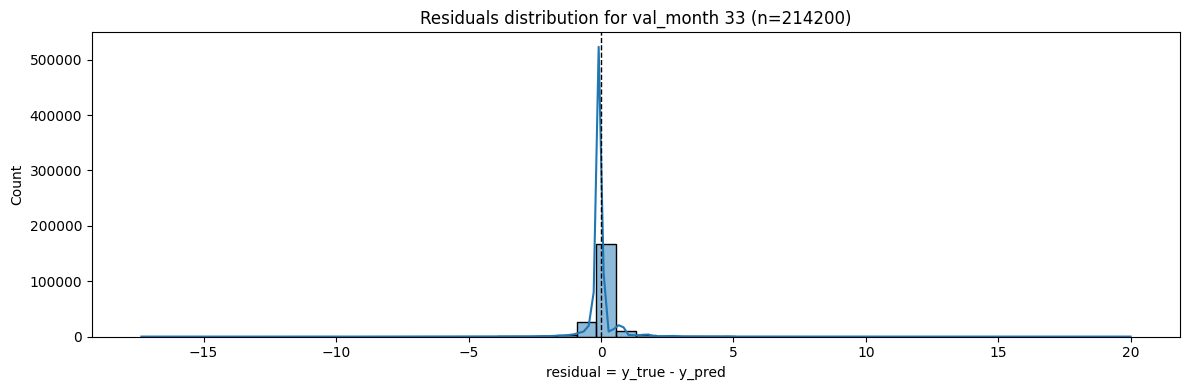

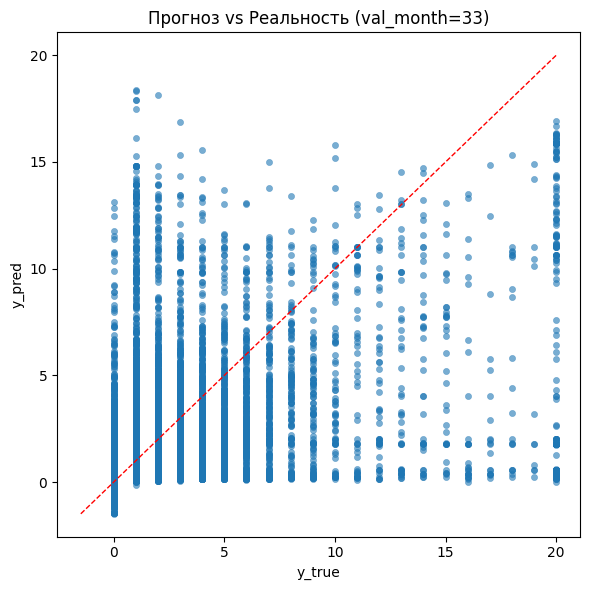

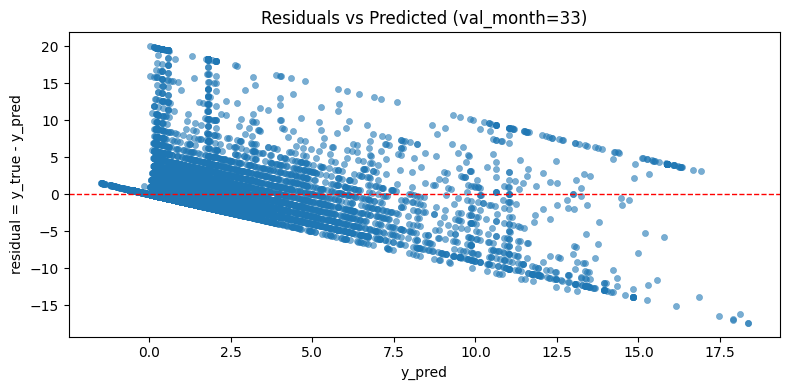

Month 33
mean_abs_residual      0.269145
median_abs_residual    0.059652
Top 20 absolute residuals for month 33:
 date_block_num  y_true   y_pred  residual  abs_residual
             33    20.0 0.011411 19.988589     19.988589
             33    20.0 0.145642 19.854358     19.854358
             33    20.0 0.149164 19.850836     19.850836
             33    20.0 0.149661 19.850339     19.850339
             33    20.0 0.206576 19.793424     19.793424
             33    20.0 0.213940 19.786060     19.786060
             33    20.0 0.214725 19.785275     19.785275
             33    20.0 0.216163 19.783837     19.783837
             33    20.0 0.235165 19.764835     19.764835
             33    20.0 0.235950 19.764050     19.764050
             33    20.0 0.241251 19.758749     19.758749
             33    20.0 0.242036 19.757964     19.757964
             33    20.0 0.243641 19.756359     19.756359
             33    20.0 0.248508 19.751492     19.751492
             33    20.0 0.251899

In [28]:
results = analyze_worst_month_residuals(folds_df, all_preds_df, validator, worst_k=3, top_n=20, figsize=(12,4))


Что можем сказать с графика:
В идеале чтобы прогнозы размещались на главной диагонали (что логично, ведь главная диагональ - это место, где совпали y_true и y_pred - значит сделали хорошее предсказание)

Большинство точек лежит ниже главной диагонали - значит модель недооценивает большие значения.


- значения маленькие таргета и их предсказанные концентрируются около нуля, то есть модель с малыми значениями справлчется хорошо, но чем выше значение таргета -  тем больше она его недооценивает
- средних у нас в принципе не так много в таргете, модель с ними не так плохо справляется